In [ ]:
import subprocess, sys, os, shutil

def pip_install(*pkgs):
    result = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])
    if result.returncode != 0:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "--break-system-packages", *pkgs],
            check=True,
        )

pip_install("pyspark==3.5.1", "pandas", "pyarrow>=16,<18", "matplotlib")

if shutil.which("java") is None:
    subprocess.run(["apt-get", "install", "-y", "-qq", "openjdk-11-jdk-headless"], check=True)
    os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
    os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

subprocess.run(["java", "-version"])


CompletedProcess(args=['java', '-version'], returncode=0)

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F, types as T
from pyspark.ml.fpm import FPGrowth
import pandas as pd

spark = (
    SparkSession.builder
    .appName("laptop-fpgrowth")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

DATA_PATH = "final_clean_filled_laptops.csv"

raw_pdf = pd.read_csv(DATA_PATH)
device_pdf = raw_pdf.drop_duplicates(subset="row_uid").copy()
print("rows loaded:", len(raw_pdf), "| unique devices:", len(device_pdf))


rows loaded: 1960 | unique devices: 1960


In [ ]:
import re

CAP_RE = re.compile(r"(\d+\.?\d*)\s*(TB|GB)", re.IGNORECASE)
BARE_NUM_RE = re.compile(r"^\d+\.?\d*$")


def bucket_ram(ram):
    if pd.isna(ram):
        return None
    if ram < 8:
        return "RAM_<8GB"
    elif ram < 16:
        return "RAM_8-16GB"
    elif ram < 32:
        return "RAM_16-32GB"
    else:
        return "RAM_32GB+"


def bucket_price(price):
    if pd.isna(price):
        return None
    if price < 400:
        return "PRICE_<400"
    elif price < 700:
        return "PRICE_400-700"
    elif price < 1200:
        return "PRICE_700-1200"
    else:
        return "PRICE_1200+"


def bucket_cpu(cpu):
    if not isinstance(cpu, str):
        return None
    c = cpu.lower()
    if "ryzen ai" in c:
        return "CPU_RyzenAI"
    if "ryzen 7" in c or "ryzen 9" in c:
        return "CPU_Ryzen7/9"
    if "ryzen 5" in c:
        return "CPU_Ryzen5"
    if "ryzen 3" in c:
        return "CPU_Ryzen3"
    if "i9" in c or "i7" in c:
        return "CPU_i7/i9"
    if "i5" in c:
        return "CPU_i5"
    if "i3" in c:
        return "CPU_i3"
    if "core ultra" in c:
        return "CPU_CoreUltra"
    if "apple" in c:
        return "CPU_AppleSilicon"
    if "celeron" in c:
        return "CPU_Celeron"
    if "pentium" in c:
        return "CPU_Pentium"
    if "snapdragon" in c or "qualcomm" in c:
        return "CPU_Snapdragon"
    return "CPU_Other"


def bucket_gpu(gpu):
    if not isinstance(gpu, str):
        return None
    g = gpu.lower()
    if "nvidia" in g or "geforce" in g or "rtx" in g or "gtx" in g or "quadro" in g:
        return "GPU_NVIDIA"
    if "radeon" in g or "amd" in g or "firepro" in g:
        return "GPU_AMD"
    if "intel" in g or "uhd graphics" in g or "hd graphics" in g or "iris" in g or "arc graphics" in g:
        return "GPU_IntelIntegrated"
    if "apple" in g:
        return "GPU_AppleIntegrated"
    if "adreno" in g or "mali" in g:
        return "GPU_MobileIntegrated"
    return "GPU_Other"


def _total_capacity_gb(s: str):
    """Sum every capacity mentioned in the string (handles dual-drive combos like
    '128GB SSD + 1TB HDD'), normalized to GB."""
    total, found = 0.0, False
    for num, unit in CAP_RE.findall(s):
        val = float(num)
        if unit.upper() == "TB":
            val *= 1024
        total += val
        found = True
    if not found and BARE_NUM_RE.match(s.strip()):
        total = float(s.strip())  
        found = True
    return total if found else None


def _bucket_capacity(gb):
    if gb is None:
        return None
    if gb < 100:
        return "STORAGE_<128GB"
    elif gb < 300:
        return "STORAGE_128-256GB"
    elif gb < 600:
        return "STORAGE_256-512GB"
    elif gb < 1100:
        return "STORAGE_512GB-1TB"
    elif gb < 2100:
        return "STORAGE_1-2TB"
    else:
        return "STORAGE_2TB+"


def bucket_storage(storage):
    if not isinstance(storage, str):
        return []
    s = storage.lower().strip()
    items = []
    cap = _bucket_capacity(_total_capacity_gb(s))
    if cap:
        items.append(cap)
    if "ssd" in s or "pcie" in s or "nvme" in s:
        items.append("STORAGE_SSD")
    if "hdd" in s:
        items.append("STORAGE_HDD")
    if "flash" in s or "emmc" in s:
        items.append("STORAGE_Flash")
    if "hybrid" in s:
        items.append("STORAGE_Hybrid")
    if "+" in s:
        items.append("STORAGE_Dual-Drive")
    return items


def build_basket(row):
    items = []
    for fn, col in [(bucket_ram, "ram_gb"), (bucket_price, "price_usd"),
                    (bucket_cpu, "cpu"), (bucket_gpu, "gpu")]:
        val = fn(row[col])
        if val:
            items.append(val)
    items.extend(bucket_storage(row["storage"]))
    return items


In [4]:
device_pdf["basket"] = device_pdf.apply(build_basket, axis=1)

before = len(device_pdf)
device_pdf = device_pdf[device_pdf["basket"].apply(len) >= 2].copy()

print(f"devices with a usable basket (>=2 tags): {len(device_pdf)} / {before}")
print(device_pdf[["title", "basket"]].head(5).to_string())


devices with a usable basket (>=2 tags): 1960 / 1960
                                                                                                                                                                                                     title                                                                                        basket
0                                                                                                  ASUS Vivobook S 16" 3K OLED Intel Core Ultra 7 255H - 32GB RAM - 1TB SSD Windows 11 Home (S5606CA-NS79)  [RAM_32GB+, PRICE_1200+, CPU_CoreUltra, GPU_IntelIntegrated, STORAGE_512GB-1TB, STORAGE_SSD]
1                                                                                   Acer Aspire Go 15 15.6" AMD Ryzen 7 5825U 48GB DDR4 Memory DDR4 3200 512GB PCIe Gen4 SSD Windows 11 Home AG15-42P-R6GZ            [RAM_32GB+, PRICE_700-1200, CPU_Ryzen7/9, GPU_AMD, STORAGE_256-512GB, STORAGE_SSD]
2                                                       

In [5]:
coverage = pd.DataFrame({
    "attribute": ["ram_gb", "price_usd", "cpu", "gpu", "storage"],
    "tagged_pct": [
        device_pdf["ram_gb"].apply(bucket_ram).notna().mean() * 100,
        device_pdf["price_usd"].apply(bucket_price).notna().mean() * 100,
        device_pdf["cpu"].apply(bucket_cpu).notna().mean() * 100,
        device_pdf["gpu"].apply(bucket_gpu).notna().mean() * 100,
        device_pdf["storage"].apply(lambda s: len(bucket_storage(s)) > 0).mean() * 100,
    ],
})
coverage["tagged_pct"] = coverage["tagged_pct"].round(1)
coverage


,attribute,tagged_pct
0,ram_gb,100.0
1,price_usd,100.0
2,cpu,100.0
3,gpu,100.0
4,storage,99.7


In [6]:
basket_sdf = spark.createDataFrame(
    device_pdf[["row_uid", "basket"]].rename(columns={"basket": "items"})
)

fp = FPGrowth(itemsCol="items", minSupport=0.05, minConfidence=0.3)
model = fp.fit(basket_sdf)

freq_itemsets = model.freqItemsets.orderBy(F.desc("freq"))
rules = model.associationRules.orderBy(F.desc("lift"))

print("=== Frequent itemsets (specs that commonly appear together) ===")
freq_itemsets.show(15, truncate=False)

print("=== Association rules (X -> Y with confidence/lift), all pairs ===")
rules.show(15, truncate=False)


=== Frequent itemsets (specs that commonly appear together) ===
+----------------------------------------+----+
|items                                   |freq|
+----------------------------------------+----+
|[GPU_IntelIntegrated]                   |1147|
|[PRICE_1200+]                           |850 |
|[STORAGE_SSD]                           |798 |
|[RAM_16-32GB]                           |637 |
|[STORAGE_128-256GB]                     |586 |
|[STORAGE_256-512GB]                     |580 |
|[RAM_8-16GB]                            |568 |
|[CPU_i7/i9]                             |568 |
|[STORAGE_512GB-1TB]                     |501 |
|[PRICE_700-1200]                        |483 |
|[CPU_i5]                                |469 |
|[STORAGE_SSD, GPU_IntelIntegrated]      |459 |
|[STORAGE_SSD, PRICE_1200+]              |451 |
|[PRICE_1200+, GPU_IntelIntegrated]      |428 |
|[STORAGE_128-256GB, GPU_IntelIntegrated]|426 |
+----------------------------------------+----+
only showing top 15 rows

In [7]:
def families(items):
    return {item.split("_")[0] for item in items}

rules_pdf = rules.select("antecedent", "consequent", "confidence", "lift", "support").toPandas()
freq_pdf = freq_itemsets.toPandas()

rules_pdf["antecedent_families"] = rules_pdf["antecedent"].apply(lambda a: families(list(a)))
rules_pdf["consequent_families"] = rules_pdf["consequent"].apply(lambda c: families(list(c)))
is_cross_spec = rules_pdf.apply(
    lambda r: r["antecedent_families"].isdisjoint(r["consequent_families"]), axis=1
)
cross_spec_rules = rules_pdf[is_cross_spec].sort_values("lift", ascending=False)

def format_rule(row):
    ante = ", ".join(row["antecedent"])
    cons = ", ".join(row["consequent"])
    return f"{ante}  ->  {cons}   (confidence={row['confidence']:.2f}, lift={row['lift']:.2f})"

cross_spec_rules = cross_spec_rules.copy()
cross_spec_rules["readable"] = cross_spec_rules.apply(format_rule, axis=1)

print(f"{len(rules_pdf)} rules total, {len(cross_spec_rules)} are genuine cross-spec associations\n")
print(cross_spec_rules[["readable"]].head(15).to_string(index=False))


472 rules total, 364 are genuine cross-spec associations

                                                                                                  readable
                            GPU_NVIDIA, PRICE_1200+  ->  STORAGE_Dual-Drive   (confidence=0.34, lift=5.09)
                                  RAM_32GB+, PRICE_1200+  ->  CPU_CoreUltra   (confidence=0.57, lift=4.31)
                            STORAGE_Dual-Drive, PRICE_1200+  ->  GPU_NVIDIA   (confidence=0.89, lift=4.23)
               STORAGE_Dual-Drive, STORAGE_SSD, PRICE_1200+  ->  GPU_NVIDIA   (confidence=0.89, lift=4.23)
             STORAGE_Dual-Drive, STORAGE_1-2TB, STORAGE_SSD  ->  GPU_NVIDIA   (confidence=0.88, lift=4.18)
                    STORAGE_1-2TB, STORAGE_HDD, STORAGE_SSD  ->  GPU_NVIDIA   (confidence=0.88, lift=4.17)
STORAGE_Dual-Drive, STORAGE_1-2TB, STORAGE_HDD, STORAGE_SSD  ->  GPU_NVIDIA   (confidence=0.88, lift=4.17)
               STORAGE_Dual-Drive, STORAGE_HDD, STORAGE_SSD  ->  GPU_NVIDIA   (confide

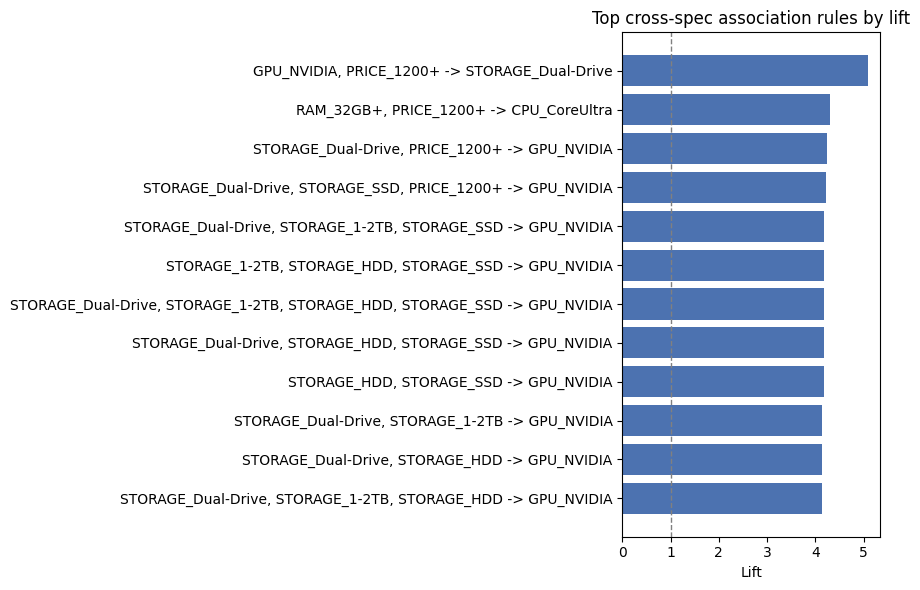

In [ ]:
import matplotlib.pyplot as plt

top = cross_spec_rules.head(12).iloc[::-1] 
labels = [f'{", ".join(a)} -> {", ".join(c)}' for a, c in zip(top["antecedent"], top["consequent"])]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels, top["lift"], color="#4C72B0")
ax.set_xlabel("Lift")
ax.set_title("Top cross-spec association rules by lift")
ax.axvline(1, color="grey", linestyle="--", linewidth=1) 
plt.tight_layout()
plt.savefig("top_cross_spec_rules.png", dpi=150)
plt.show()


In [ ]:
drop_cols = ["antecedent_families", "consequent_families"]
rules_pdf.drop(columns=drop_cols).to_csv("fpgrowth_association_rules.csv", index=False)
cross_spec_rules.drop(columns=drop_cols).to_csv("fpgrowth_cross_spec_rules.csv", index=False)
freq_pdf.to_csv("fpgrowth_frequent_itemsets.csv", index=False)

print("saved fpgrowth_association_rules.csv:", len(rules_pdf), "rows")
print("saved fpgrowth_cross_spec_rules.csv:", len(cross_spec_rules), "rows")
print("saved fpgrowth_frequent_itemsets.csv:", len(freq_pdf), "rows")

try:
    from google.colab import files
    files.download("fpgrowth_association_rules.csv")
    files.download("fpgrowth_cross_spec_rules.csv")
    files.download("fpgrowth_frequent_itemsets.csv")
except ImportError:
    pass 


saved fpgrowth_association_rules.csv: 472 rows
saved fpgrowth_cross_spec_rules.csv: 364 rows
saved fpgrowth_frequent_itemsets.csv: 243 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
def get_paired_specs(item_bucket: str, rules_df: pd.DataFrame = cross_spec_rules, top_n: int = 3):
    """Given one spec bucket (e.g. 'CPU_Ryzen7/9'), return the top commonly-paired specs
    from *other* spec categories."""
    matches = rules_df[rules_df["antecedent"].apply(lambda a: item_bucket in a and len(a) == 1)]
    matches = matches.sort_values("lift", ascending=False).head(top_n)
    return [
        {"paired_with": ", ".join(row["consequent"]),
         "confidence": round(row["confidence"], 2),
         "lift": round(row["lift"], 2)}
        for _, row in matches.iterrows()
    ]

get_paired_specs("CPU_CoreUltra")


[{'paired_with': 'RAM_32GB+', 'confidence': 0.61, 'lift': 3.17},
 {'paired_with': 'PRICE_1200+', 'confidence': 0.85, 'lift': 1.95},
 {'paired_with': 'STORAGE_512GB-1TB', 'confidence': 0.42, 'lift': 1.65}]

In [11]:
spark.stop()
